# Ver.5 実装前チェック（VG1GC-66）

[docs/requirements_ver5.md](../docs/requirements_ver5.md) の設計レビューで挙がった「実装前にやると安い確認」4件を実行するノート。Ver.5本体の実装ではなく、**着手前に前提が成り立っているかを確かめるための記述統計・小規模フィット**に限定する。

| # | 確認内容 | 何が分かれば良いか |
| :--- | :--- | :--- |
| 1 | 日別の学習曲線と day6 の点検 | Day 1–15がこの個体で実際に学習過程を張っているか。5.2節のランダムウォーク事前分布が前提とする「day間の緩やかな変化」が成り立つか |
| 2 | Short Pull の3類型分解と時間的まとまり | 系統B（3値）が区別しようとしている境界に、状態が捉えうる系統的構造があるか。センサーの接触判定由来の成分を除いても残るか |
| 3 | $P(z)\geq0.8$ の残存率と 状態×試行タイプ のday別セル数 | 6節の皮質デコード（閾値・バランシング）が試行数的に成立するか |
| 4 | `ssm` の `InputDrivenObservations(C=3)` で3値静的GLM-HMMが回るか | 系統Bの静的フィット（5.4節Step (1)）に自前実装が要るか |

前提: `VG1GC-66` の全14 task-day（day1, 3–15）のNWBがローカルに揃っていること（[docs/data.md](../docs/data.md)）。

## 0. セットアップ

In [1]:
import sys, os
from pathlib import Path

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    pass

if IN_COLAB:
    drive.mount('/content/drive')
    repo_path = Path('/content/braidyn-bc')
    if not repo_path.exists():
        os.system('git clone https://github.com/nyaamikeneko/braidyn-bc.git /content/braidyn-bc')
    os.chdir(repo_path)
else:
    here = Path.cwd()
    repo_root = here if (here / 'config.py').exists() else here.parent
    os.chdir(repo_root)

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))
print('cwd:', Path.cwd())

cwd: /mnt/c/Users/dmasu/braidyn-bc


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import config
import src.glmhmm_ver4 as v4

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

MOUSE_ID = 'VG1GC-66'
ALPHA_ACT = v4.ALPHA_ACT   # 0.65
ALPHA_REW = v4.ALPHA_REW   # 0.80
SOUND_TYPES = ['Success', 'Short Pull', 'No Reaction']
NUM_STATES = 3
PRIOR_SIGMA = v4.PRIOR_SIGMA
SEEDS = [0, 1, 2]
NUM_ITERS = 200
P_THRESHOLD = 0.80   # 6.1節 Aloor式の状態割り当て閾値

print(f'mouse={MOUSE_ID} alpha_act={ALPHA_ACT} alpha_rew={ALPHA_REW}')

環境: ローカル (WSL)
DATA_CSV_ROOT: /mnt/g/.shortcut-targets-by-id/1fI6PWRHgihU6asA4OyW-_rN-JII33Fkj/hackathon_data
DATA_CSV_BACKUP_ROOT: /mnt/g/マイドライブ/braidyn-bc-backup/hackathon_data


mouse=VG1GC-66 alpha_act=0.65 alpha_rew=0.8


## 1. Ver.5の試行系列を作る

[requirements_ver5.md](../docs/requirements_ver5.md) 2.1節に従い、Ver.4の試行テーブルから**音提示試行のみ**（Success / Short Pull / No Reaction）を取り出して単一系列にする。No Sound Pull と Second Pull は落とす。

入力（4.2節）はこの音提示試行だけの系列で計算し直す。History のday境界での扱いは要件に規定が無いので、**ここではday頭でリセット**する（Ver.4の `add_history` と同じ挙動）。History 2列は4.2節に従い全日プールでz-score化する。

In [3]:
dataset = v4.process_mouse(MOUSE_ID, alpha_act=ALPHA_ACT, alpha_rew=ALPHA_REW)
trials_all = dataset['trials']
print()
print('Ver.4 全試行タイプの内訳:')
print(trials_all['trial_type'].value_counts())
print('task_days:', dataset['task_days'])

CSV読み込み中: /mnt/g/.shortcut-targets-by-id/1fI6PWRHgihU6asA4OyW-_rN-JII33Fkj/hackathon_data/VG1GC-66/task-day1/trials_L1L2.csv


全試行数: 54000
NWB読み込み中: /mnt/g/マイドライブ/nwb_manual/VG1GC-66/VG1GC-66_2023-08-21_task-day1.nwb


VG1GC-66 task-day1: 787 trials, face=yes
CSV読み込み中: /mnt/g/.shortcut-targets-by-id/1fI6PWRHgihU6asA4OyW-_rN-JII33Fkj/hackathon_data/VG1GC-66/task-day3/trials_L1L2.csv
全試行数: 54000
NWB読み込み中: /mnt/g/マイドライブ/nwb_manual/VG1GC-66/VG1GC-66_2023-08-23_task-day3.nwb


VG1GC-66 task-day3: 548 trials, face=yes
CSV読み込み中: /mnt/g/.shortcut-targets-by-id/1fI6PWRHgihU6asA4OyW-_rN-JII33Fkj/hackathon_data/VG1GC-66/task-day4/trials_L1L2.csv
全試行数: 54000
NWB読み込み中: /mnt/g/マイドライブ/nwb_manual/VG1GC-66/VG1GC-66_2023-08-24_task-day4.nwb


VG1GC-66 task-day4: 470 trials, face=yes
CSV読み込み中: /mnt/g/.shortcut-targets-by-id/1fI6PWRHgihU6asA4OyW-_rN-JII33Fkj/hackathon_data/VG1GC-66/task-day5/trials_L1L2.csv
全試行数: 54000
NWB読み込み中: /mnt/g/マイドライブ/nwb_manual/VG1GC-66/VG1GC-66_2023-08-25_task-day5.nwb


...

VG1GC-66 task-day13: 509 trials, face=yes
CSV読み込み中: /mnt/g/.shortcut-targets-by-id/1fI6PWRHgihU6asA4OyW-_rN-JII33Fkj/hackathon_data/VG1GC-66/task-day14/trials_L1L2.csv
全試行数: 54000


NWB読み込み中: /mnt/g/マイドライブ/nwb_manual/VG1GC-66/VG1GC-66_2023-09-07_task-day14.nwb


VG1GC-66 task-day14: 393 trials, face=yes
CSV読み込み中: /mnt/g/.shortcut-targets-by-id/1fI6PWRHgihU6asA4OyW-_rN-JII33Fkj/hackathon_data/VG1GC-66/task-day15/trials_L1L2.csv


全試行数: 54000
NWB読み込み中: /mnt/g/マイドライブ/nwb_manual/VG1GC-66/VG1GC-66_2023-09-08_task-day15.nwb


VG1GC-66 task-day15: 498 trials, face=yes

Ver.4 全試行タイプの内訳:
trial_type
No Sound Pull    4386
Success          1293
No Reaction       555
Short Pull        511
Name: count, dtype: int64
task_days: ['task-day1', 'task-day3', 'task-day4', 'task-day5', 'task-day6', 'task-day7', 'task-day8', 'task-day9', 'task-day10', 'task-day11', 'task-day12', 'task-day13', 'task-day14', 'task-day15']


In [4]:
def build_ver5_sequence(trials_all, alpha_act=ALPHA_ACT, alpha_rew=ALPHA_REW):
    # 音提示試行のみの系列を作り、その系列上でHistoryを計算し直す（day頭でリセット）
    out = []
    for day, g in trials_all.groupby('task_day', sort=False):
        g = g[g['trial_type'].isin(SOUND_TYPES)].sort_values('t_start').reset_index(drop=True).copy()
        a = (g['trial_type'] != 'No Reaction').astype(int).to_numpy()
        rw = (g['trial_type'] == 'Success').astype(int).to_numpy()
        n = len(g)
        h = np.zeros(n); r = np.zeros(n)
        for k in range(1, n):
            h[k] = a[k - 1] + alpha_act * h[k - 1]
            r[k] = rw[k - 1] + alpha_rew * r[k - 1]
        g['a'] = a
        g['reward_bin'] = rw
        g['x_bias'] = 1.0
        g['x_hist'] = h
        g['x_rew'] = r
        g['yA'] = a
        g['yB'] = g['trial_type'].map({'Success': 0, 'Short Pull': 1, 'No Reaction': 2}).astype(int)
        g['k'] = np.arange(n)
        out.append(g)
    return pd.concat(out, ignore_index=True)

tr = build_ver5_sequence(trials_all)

# 4.2節: History 2列は全日プールでz-score化（Bias列はそのまま）
ZSTATS = {}
for c in ['x_hist', 'x_rew']:
    mu, sd = float(tr[c].mean()), float(tr[c].std(ddof=0))
    ZSTATS[c] = (mu, sd)
    tr[c + '_z'] = (tr[c] - mu) / sd
INPUT_COLS = ['x_bias', 'x_hist_z', 'x_rew_z']

DAYS = list(dict.fromkeys(tr['task_day'].tolist()))
print('days:', len(DAYS), DAYS)
print('音提示試行 総数:', len(tr))
print(tr['trial_type'].value_counts())
print()
print('z-score前の入力レンジ（4.2節の標準化の根拠）:')
print(tr[['x_bias', 'x_hist', 'x_rew']].describe().loc[['min', 'max', 'mean', 'std']].round(3))
print('z-score統計 (mean, sd):', {k: (round(v[0], 3), round(v[1], 3)) for k, v in ZSTATS.items()})

days: 14 ['task-day1', 'task-day3', 'task-day4', 'task-day5', 'task-day6', 'task-day7', 'task-day8', 'task-day9', 'task-day10', 'task-day11', 'task-day12', 'task-day13', 'task-day14', 'task-day15']
音提示試行 総数: 2359
trial_type
Success        1293
No Reaction     555
Short Pull      511
Name: count, dtype: int64

z-score前の入力レンジ（4.2節の標準化の根拠）:
      x_bias  x_hist  x_rew
min      1.0   0.000  0.000
max      1.0   2.857  4.994
mean     1.0   2.145  2.649
std      0.0   0.860  1.318
z-score統計 (mean, sd): {'x_hist': (2.145, 0.86), 'x_rew': (2.649, 1.318)}


## 2. チェック1: 日別の学習曲線と day6 の点検

要件5.2節のランダムウォーク事前分布は「dayをまたいで重みが緩やかに変化する」ことを前提にしている。またRQ2は「Day 1–15が学習過程を張っている」ことを前提にしている。まずこの2つの前提を行動データだけで確かめる。

In [5]:
rows = []
for day in DAYS:
    g = tr[tr['task_day'] == day]
    n = len(g)
    n_pull = int((g['trial_type'] != 'No Reaction').sum())
    n_succ = int((g['trial_type'] == 'Success').sum())
    thr = g['pull_duration_for_success'].dropna()
    rows.append({
        'task_day': day,
        'n_trials': n,
        'p_no_reaction': (g['trial_type'] == 'No Reaction').mean(),
        'p_success_all': n_succ / n,
        'p_success_given_pull': (n_succ / n_pull) if n_pull else np.nan,
        'n_pull': n_pull,
        'thr_median': float(thr.median()) if len(thr) else np.nan,
        'thr_min': float(thr.min()) if len(thr) else np.nan,
        'thr_max': float(thr.max()) if len(thr) else np.nan,
    })
day_stats = pd.DataFrame(rows)
day_stats['day_idx'] = np.arange(1, len(day_stats) + 1)
day_stats['day_num'] = day_stats['task_day'].str.extract(r'(\d+)$').astype(int)
print(day_stats.round(3).to_string(index=False))

  task_day  n_trials  p_no_reaction  p_success_all  p_success_given_pull  n_pull  thr_median  thr_min  thr_max  day_idx  day_num
 task-day1        76          0.421          0.579                 1.000      44        0.00     0.00     0.05        1        1
 task-day3       156          0.346          0.571                 0.873     102        0.05     0.00     0.15        2        3
 task-day4       103          0.049          0.883                 0.929      98        0.15     0.05     0.30        3        4
 task-day5       183          0.098          0.749                 0.830     165        0.40     0.30     0.40        4        5
 task-day6       318          0.610          0.280                 0.718     124        0.40     0.30     0.40        5        6
 task-day7       157          0.070          0.726                 0.781     146        0.40     0.30     0.40        6        7
 task-day8       153          0.235          0.438                 0.573     117        0.30     

In [6]:
def trend(y, x):
    y = np.asarray(y, dtype=float); x = np.asarray(x, dtype=float)
    ok = np.isfinite(y) & np.isfinite(x)
    rho, p_s = stats.spearmanr(x[ok], y[ok])
    r, p_p = stats.pearsonr(x[ok], y[ok])
    return rho, p_s, r, p_p

print('day index に対する単調傾向（n=14 day）')
print(f"{'metric':24s} {'spearman':>9s} {'p':>7s} {'pearson':>9s} {'p':>7s}")
for m in ['p_no_reaction', 'p_success_all', 'p_success_given_pull', 'thr_median', 'n_trials']:
    rho, ps, r, pp = trend(day_stats[m], day_stats['day_idx'])
    print(f'{m:24s} {rho:9.3f} {ps:7.3f} {r:9.3f} {pp:7.3f}')

dnr = day_stats['p_no_reaction'].to_numpy()
print()
print('隣接day間の No Reaction率 の変化量:', np.round(np.abs(np.diff(dnr)), 3))
print(f'  平均 {np.abs(np.diff(dnr)).mean():.3f} / 最大 {np.abs(np.diff(dnr)).max():.3f}')

day index に対する単調傾向（n=14 day）
metric                    spearman       p   pearson       p
p_no_reaction               -0.086   0.771    -0.223   0.443
p_success_all               -0.354   0.215    -0.298   0.301
p_success_given_pull        -0.670   0.009    -0.718   0.004
thr_median                   0.069   0.815     0.018   0.951
n_trials                     0.317   0.270     0.272   0.347

隣接day間の No Reaction率 の変化量: [0.075 0.298 0.05  0.512 0.54  0.165 0.055 0.11  0.015 0.129 0.024 0.113
 0.193]
  平均 0.175 / 最大 0.540


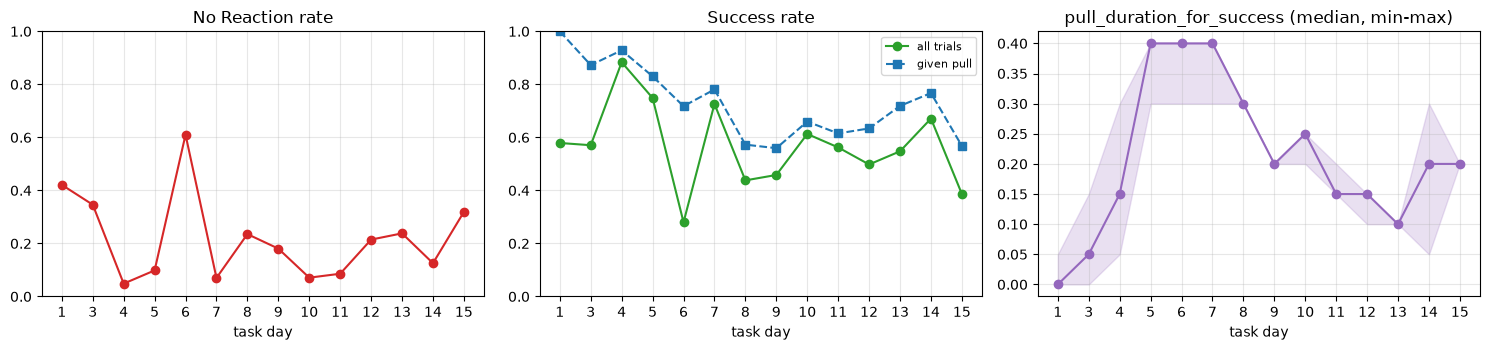

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
x = day_stats['day_idx']
labels = day_stats['day_num'].astype(str)

axes[0].plot(x, day_stats['p_no_reaction'], 'o-', color='#d62728')
axes[0].set_title('No Reaction rate'); axes[0].set_ylim(0, 1)
axes[1].plot(x, day_stats['p_success_all'], 'o-', color='#2ca02c', label='all trials')
axes[1].plot(x, day_stats['p_success_given_pull'], 's--', color='#1f77b4', label='given pull')
axes[1].set_title('Success rate'); axes[1].set_ylim(0, 1); axes[1].legend(fontsize=8)
axes[2].plot(x, day_stats['thr_median'], 'o-', color='#9467bd')
axes[2].fill_between(x, day_stats['thr_min'], day_stats['thr_max'], alpha=.2, color='#9467bd')
axes[2].set_title('pull_duration_for_success (median, min-max)')
for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_xlabel('task day'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [8]:
# セッションレベルの点検（day6の外れ値性を含む）
rows = []
for pack in dataset['sessions']:
    day = pack['trials']['task_day'].iloc[0]
    cl = pack['cleaned']
    g = tr[tr['task_day'] == day]
    dur_min = (cl['t'].max() - cl['t'].min()) / 60.0
    iti = cl['state_task'].eq(0).mean()
    thirds = np.array_split(g['trial_type'].to_numpy(), 3)
    nr3 = [float((t == 'No Reaction').mean()) for t in thirds]
    rows.append({
        'task_day': day, 'session_min': dur_min, 'n_trials': len(g),
        'trials_per_min': len(g) / dur_min,
        'frac_ITI_time': iti,
        'NR_1st': nr3[0], 'NR_2nd': nr3[1], 'NR_3rd': nr3[2],
    })
sess = pd.DataFrame(rows)
print(sess.round(3).to_string(index=False))
print()
sess['z_trials_per_min'] = (sess['trials_per_min'] - sess['trials_per_min'].mean()) / sess['trials_per_min'].std(ddof=0)
print('day6 の位置づけ:')
print(sess[sess['task_day'].str.endswith('day6')].round(3).to_string(index=False))

  task_day  session_min  n_trials  trials_per_min  frac_ITI_time  NR_1st  NR_2nd  NR_3rd
 task-day1         30.0        76           2.533          0.926   0.615   0.320   0.320
 task-day3         30.0       156           5.200          0.852   0.404   0.423   0.212
 task-day4         30.0       103           3.433          0.876   0.057   0.088   0.000
 task-day5         30.0       183           6.100          0.786   0.066   0.131   0.098
 task-day6         30.0       318          10.600          0.758   0.160   0.736   0.934
 task-day7         30.0       157           5.233          0.825   0.113   0.000   0.096
 task-day8         30.0       153           5.100          0.879   0.098   0.333   0.275
 task-day9         30.0        72           2.400          0.943   0.167   0.208   0.167
task-day10         30.0       155           5.167          0.854   0.038   0.019   0.157
task-day11         30.0       233           7.767          0.792   0.051   0.077   0.130
task-day12         30

## 3. チェック2: Short Pull の3類型分解

[data.md](../docs/data.md)・[CLAUDE.md](../CLAUDE.md) の記述に従い、Short Pull を次の3類型に分ける。

* **引き足りない (too_short)**: 測定 `pull_duration` < `pull_duration_for_success`
* **締め切り超過 (deadline)**: 閾値ぶんは引けているが、引き始めの遅れ（`t_onset - t_start`）＋閾値 が締め切りを超える
* **接触途切れ (dropout)**: 上記いずれでもない（行動としては閾値以上引けており、課題側が接触途切れで確定させた）

締め切りはNo Reaction試行の `stop_time - start_time` の中央値から実測で決める。

In [9]:
nr_tr = tr[tr['trial_type'] == 'No Reaction']
DEADLINE = float((nr_tr['t_end'] - nr_tr['t_start']).median())
print(f'締め切り（No Reaction試行の窓長の中央値）: {DEADLINE:.4f} 秒')
print('  分布 (0/25/50/75/100%):',
      np.round(np.percentile((nr_tr['t_end'] - nr_tr['t_start']).dropna(), [0, 25, 50, 75, 100]), 4))

sp = tr[tr['trial_type'] == 'Short Pull'].copy()
sp['rt'] = sp['t_onset'] - sp['t_start']

def classify(row):
    dur, thr, rt = row['pull_duration'], row['pull_duration_for_success'], row['rt']
    if not np.isfinite(dur):
        return 'unmeasured'
    if np.isfinite(thr) and dur < thr:
        return 'too_short'
    if np.isfinite(thr) and np.isfinite(rt) and (rt + thr) > DEADLINE:
        return 'deadline'
    return 'dropout'

sp['sp_subtype'] = sp.apply(classify, axis=1)
cnt = sp['sp_subtype'].value_counts()
print()
print('Short Pull の内訳 (n=%d):' % len(sp))
for k, v in cnt.items():
    print(f'  {k:12s} {v:5d}  {v / len(sp) * 100:5.1f}%')
print()
print('day別:')
print(pd.crosstab(sp['task_day'], sp['sp_subtype']).to_string())

tr['sp_subtype'] = ''
tr.loc[sp.index, 'sp_subtype'] = sp['sp_subtype']

締め切り（No Reaction試行の窓長の中央値）: 1.0000 秒
  分布 (0/25/50/75/100%): [1.     1.     1.     1.     1.0334]

Short Pull の内訳 (n=511):
  dropout        317   62.0%
  too_short      184   36.0%
  deadline         9    1.8%
  unmeasured       1    0.2%

day別:
sp_subtype  deadline  dropout  too_short  unmeasured
task_day                                            
task-day10         3       35         11           0
task-day11         0       59         23           0
task-day12         0       48         18           1
task-day13         2       13         12           0
task-day14         0       36         11           0
task-day15         3       26         19           0
task-day3          0        8          5           0
task-day4          0        5          2           0
task-day5          0       17         11           0
task-day6          0        7         28           0
task-day7          0       14         18           0
task-day8          0       34         16           0
task-day9   

### 3.1 時間的なまとまりがあるか

HMMの状態がカテゴリの出方を説明できるためには、そのカテゴリが**系列内でまとまって出現する**必要がある（状態は持続するため）。ラベル系列のlag-1自己相関と runs test（Wald–Wolfowitz）で、独立ベルヌーイからの逸脱を測る。runs test の z は、負なら run 数が期待より少ない＝まとまりがあることを意味する。

* `yA`（反応したか）: 系統Aが説明する量。比較の基準になる。
* `Short Pull | pulled`: 系統Bが系統Aに加えて説明しようとしている量。
* `Short Pull | pulled, 接触途切れ型を除く`: 上記からセンサー由来の成分を落としたもの。

In [10]:
def runs_z(b):
    b = np.asarray(b, dtype=int)
    n = len(b); n1 = int(b.sum()); n0 = n - n1
    if n1 == 0 or n0 == 0 or n < 20:
        return np.nan
    R = 1 + int((np.diff(b) != 0).sum())
    mu = 2 * n1 * n0 / n + 1
    var = (mu - 1) * (mu - 2) / (n - 1)
    if var <= 0:
        return np.nan
    return (R - mu) / np.sqrt(var)

def lag1(b):
    b = np.asarray(b, dtype=float)
    if len(b) < 20 or b.std() == 0:
        return np.nan
    return float(np.corrcoef(b[:-1], b[1:])[0, 1])

def summarize(seq_by_day, label):
    zs, acs, ns = [], [], []
    for day, b in seq_by_day:
        z, a = runs_z(b), lag1(b)
        if np.isfinite(z): zs.append(z)
        if np.isfinite(a): acs.append(a)
        ns.append(len(b))
    zs = np.array(zs); acs = np.array(acs)
    stouffer = zs.sum() / np.sqrt(len(zs)) if len(zs) else np.nan
    p = 2 * stats.norm.sf(abs(stouffer)) if np.isfinite(stouffer) else np.nan
    print(label)
    print(f'  使用day数 {len(zs)} / 系列長 中央値 {int(np.median(ns))}')
    print(f'  lag-1 自己相関: 平均 {np.nanmean(acs):+.3f}  (day別: {np.round(acs, 2)})')
    print(f'  runs test z: 平均 {zs.mean():+.2f}  Stouffer合成 z={stouffer:+.2f}  p={p:.2e}')
    print(f'  z<-1.96 のday数（まとまりあり）: {(zs < -1.96).sum()} / {len(zs)}')
    return stouffer, float(np.nanmean(acs))

seq_yA = [(d, tr.loc[tr['task_day'] == d, 'yA'].to_numpy()) for d in DAYS]
res = {}
res['yA'] = summarize(seq_yA, 'A) yA（cueに反応したか、全音提示試行）')
print()

pulled = tr[tr['trial_type'] != 'No Reaction']
seq_sp = [(d, (pulled.loc[pulled['task_day'] == d, 'trial_type'] == 'Short Pull').astype(int).to_numpy())
          for d in DAYS]
res['short'] = summarize(seq_sp, 'B) Short Pull か（押下試行のみの部分系列）')
print()

pulled_nodrop = pulled[pulled['sp_subtype'] != 'dropout']
seq_sp2 = [(d, (pulled_nodrop.loc[pulled_nodrop['task_day'] == d, 'trial_type'] == 'Short Pull').astype(int).to_numpy())
           for d in DAYS]
res['short_nodrop'] = summarize(seq_sp2, 'C) Short Pull か（押下試行、接触途切れ型を除外）')

A) yA（cueに反応したか、全音提示試行）
  使用day数 14 / 系列長 中央値 156
  lag-1 自己相関: 平均 +0.249  (day別: [ 0.24  0.2   0.37  0.38  0.56  0.41  0.05  0.06  0.31  0.19  0.26 -0.01
  0.21  0.25])
  runs test z: 平均 -3.43  Stouffer合成 z=-12.83  p=1.07e-37
  z<-1.96 のday数（まとまりあり）: 11 / 14

B) Short Pull か（押下試行のみの部分系列）
  使用day数 13 / 系列長 中央値 120
  lag-1 自己相関: 平均 +0.047  (day別: [ 0.12 -0.08  0.31  0.16 -0.   -0.02  0.09  0.05  0.05  0.05 -0.09  0.03
 -0.06])
  runs test z: 平均 -0.65  Stouffer合成 z=-2.34  p=1.95e-02
  z<-1.96 のday数（まとまりあり）: 1 / 13

C) Short Pull か（押下試行、接触途切れ型を除外）
  使用day数 13 / 系列長 中央値 101
  lag-1 自己相関: 平均 +0.079  (day別: [ 0.15 -0.02  0.12  0.29 -0.03 -0.01  0.27  0.02 -0.02  0.14 -0.03  0.03
  0.14])
  runs test z: 平均 -0.80  Stouffer合成 z=-2.88  p=3.93e-03
  z<-1.96 のday数（まとまりあり）: 1 / 13


### 3.2 3次元入力から予測できるか

系統BがSuccess/Short Pullを分けるのに使えるのは4.2節の3次元入力だけである。その3次元から Short Pull かどうかがどれだけ予測できるかを、5-fold CVの対数損失で切片のみのモデルと比べる。改善がほぼ無ければ、状態別GLMがこの境界に与えられる説明力も限られる。

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss

def cv_gain(X, y, label, n_splits=5, seed=0):
    X = np.asarray(X, dtype=float); y = np.asarray(y, dtype=int)
    if len(np.unique(y)) < 2 or min(np.bincount(y)) < n_splits:
        print(f'{label}: サンプル不足でスキップ'); return np.nan
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    ll_m, ll_b = [], []
    for tr_i, te_i in skf.split(X, y):
        m = LogisticRegression(max_iter=2000, C=1.0)
        m.fit(X[tr_i], y[tr_i])
        ll_m.append(log_loss(y[te_i], m.predict_proba(X[te_i])[:, 1], labels=[0, 1]))
        p = np.clip(y[tr_i].mean(), 1e-6, 1 - 1e-6)
        ll_b.append(log_loss(y[te_i], np.full(len(te_i), p), labels=[0, 1]))
    gain = np.mean(ll_b) - np.mean(ll_m)
    print(label)
    print(f'  n={len(y)}  陽性率={y.mean():.3f}  切片のみ logloss={np.mean(ll_b):.4f}  '
          f'3次元入力 logloss={np.mean(ll_m):.4f}  改善={gain:+.4f}')
    return gain

feat = ['x_bias', 'x_hist_z', 'x_rew_z']
print('（Biasは定数なので実質2次元。改善は nats/試行）')
gA = cv_gain(tr[feat], tr['yA'], 'A) yA ~ 入力（全音提示試行）')
print()
gB = cv_gain(pulled[feat], (pulled['trial_type'] == 'Short Pull').astype(int),
             'B) Short Pull ~ 入力（押下試行のみ）')
print()
gC = cv_gain(pulled_nodrop[feat], (pulled_nodrop['trial_type'] == 'Short Pull').astype(int),
             'C) Short Pull ~ 入力（押下試行、接触途切れ型を除外）')

（Biasは定数なので実質2次元。改善は nats/試行）


A) yA ~ 入力（全音提示試行）
  n=2359  陽性率=0.765  切片のみ logloss=0.5456  3次元入力 logloss=0.4398  改善=+0.1058

B) Short Pull ~ 入力（押下試行のみ）
  n=1804  陽性率=0.283  切片のみ logloss=0.5960  3次元入力 logloss=0.5846  改善=+0.0114



C) Short Pull ~ 入力（押下試行、接触途切れ型を除外）
  n=1487  陽性率=0.130  切片のみ logloss=0.3873  3次元入力 logloss=0.3799  改善=+0.0074


## 4. チェック3: $P(z)\geq0.8$ の残存率と 状態×試行タイプ のday別セル数

6.1節はAloorに倣い $P(z)\geq0.8$ で状態を確定させ、6.4節はday内で状態×試行タイプの試行数を釣り合わせる。この2つを通した後にday別で何試行残るかを見積もる。

ここで使うのは**Ver.5の 5.4節 Step (1)（全day連結の静的GLM-HMM）**に相当するモデル。動的部分（$\alpha$, $\kappa$）は未実装なので、静的フィットでの残存率を目安として読む。

In [12]:
ys, xs = [], []
for d in DAYS:
    g = tr[tr['task_day'] == d]
    ys.append(g[['yA']].to_numpy(dtype=int))
    xs.append(g[INPUT_COLS].to_numpy(dtype=float))
print('sequences:', len(ys), 'trials:', sum(len(y) for y in ys), 'input dim:', xs[0].shape[1])

modelA, llsA, bestA = v4.train_glmhmm_map(
    ys, xs, num_states=NUM_STATES, prior_sigma=PRIOR_SIGMA, num_iters=NUM_ITERS, seeds=SEEDS
)
zA, pA = v4.decode_states(modelA, ys, xs)
trA = v4.attach_decoded_states(tr, zA, pA)
pcols = [c for c in trA.columns if c.startswith('p_state_')]
trA['p_max'] = trA[pcols].max(axis=1)
print()
print('最尤状態の事後確率 p_max の分布:')
print(trA['p_max'].describe().round(3))

sequences: 14 trials: 2359 input dim: 3


Training GLM-HMM K=3 M=3 prior_sigma=2.0


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-1006.11


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-1004.26


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-1006.02
Best log_prob=-1004.26



最尤状態の事後確率 p_max の分布:
count    2359.000
mean        0.927
std         0.124
min         0.493
25%         0.926
50%         0.992
75%         0.999
max         1.000
Name: p_max, dtype: float64


In [13]:
print(f'閾値 P(z)>={P_THRESHOLD} の残存率')
overall = (trA['p_max'] >= P_THRESHOLD).mean()
print(f'  全体: {overall:.3f}  ({int((trA["p_max"] >= P_THRESHOLD).sum())} / {len(trA)} 試行)')
ret = trA.groupby('task_day', sort=False)['p_max'].apply(lambda s: (s >= P_THRESHOLD).mean())
print('  day別:')
print(ret.round(3).to_string())

kept = trA[trA['p_max'] >= P_THRESHOLD]
print()
print('残存試行の 状態×試行タイプ（全day合計）:')
print(pd.crosstab(kept['state'], kept['trial_type']).to_string())

閾値 P(z)>=0.8 の残存率
  全体: 0.844  (1991 / 2359 試行)
  day別:
task_day
task-day1     1.000
task-day3     0.923
task-day4     1.000
task-day5     0.858
task-day6     0.755
task-day7     1.000
task-day8     0.797
task-day9     0.125
task-day10    0.761
task-day11    0.828
task-day12    0.927
task-day13    0.952
task-day14    0.814
task-day15    0.908

残存試行の 状態×試行タイプ（全day合計）:
trial_type  No Reaction  Short Pull  Success
state                                       
0                   258         167      399
1                   178          21       22
2                    63         232      651


In [14]:
# 6.4節のバランシング（day内で状態×試行タイプを釣り合わせる）後に何試行使えるか
rows = []
for d in DAYS:
    g = kept[kept['task_day'] == d]
    ct = pd.crosstab(g['trial_type'], g['state'])
    ct = ct.reindex(index=SOUND_TYPES, columns=range(NUM_STATES), fill_value=0)
    per_type_min = ct.min(axis=1)
    usable = int((per_type_min * NUM_STATES).sum())
    rows.append({
        'task_day': d,
        'n_all': int((trA['task_day'] == d).sum()),
        'n_kept': len(g),
        'n_states_present': int((ct.sum(axis=0) > 0).sum()),
        'min_cell': int(ct.values.min()),
        'usable_balanced': usable,
        'usable_per_state': usable // NUM_STATES,
    })
bal = pd.DataFrame(rows)
print(bal.to_string(index=False))
print()
print(f'day別 balanced 使用可能試行数: 中央値 {bal["usable_balanced"].median():.0f}, '
      f'最小 {bal["usable_balanced"].min()}, 最大 {bal["usable_balanced"].max()}')
print(f'全day合計: {bal["usable_balanced"].sum()} 試行')
print(f'min_cell=0 のday数: {(bal["min_cell"] == 0).sum()} / {len(bal)}')

  task_day  n_all  n_kept  n_states_present  min_cell  usable_balanced  usable_per_state
 task-day1     76      76                 1         0                0                 0
 task-day3    156     144                 1         0                0                 0
 task-day4    103     103                 1         0                0                 0
 task-day5    183     157                 1         0                0                 0
 task-day6    318     240                 2         0                0                 0
 task-day7    157     157                 1         0                0                 0
 task-day8    153     122                 1         0                0                 0
 task-day9     72       9                 1         0                0                 0
task-day10    155     118                 1         0                0                 0
task-day11    233     193                 1         0                0                 0
task-day12    233    

In [15]:
# 閾値をかけない状態占有（day別）。状態がday単位に分かれてしまっていないかの確認。
occ = pd.crosstab(trA['task_day'], trA['state']).reindex(DAYS)
occ_frac = occ.div(occ.sum(axis=1), axis=0)
print('day別 状態占有数（閾値なし・全試行）:')
print(occ.to_string())
print()
print('day別 状態占有率:')
print(occ_frac.round(3).to_string())
print()
n_states_day = (occ > 0).sum(axis=1)
dom = occ_frac.max(axis=1)
print('dayごとに出現した状態数:', n_states_day.to_dict())
print(f'最頻状態の占有率: 中央値 {dom.median():.3f} / 最小 {dom.min():.3f} / 最大 {dom.max():.3f}')
print(f'1状態が90%以上を占めるday: {int((dom >= 0.9).sum())} / {len(dom)}')

print()
print('状態のrun長（Viterbi系列、day内で連続する同一状態の長さ）:')
runs = []
for d in DAYS:
    z = trA.loc[trA['task_day'] == d, 'state'].to_numpy()
    if len(z) == 0:
        continue
    cut = np.flatnonzero(np.diff(z) != 0) + 1
    for seg in np.split(z, cut):
        runs.append((int(seg[0]), len(seg)))
rdf = pd.DataFrame(runs, columns=['state', 'run_len'])
print(rdf.groupby('state')['run_len'].agg(['count', 'mean', 'median', 'max']).round(2).to_string())
print(f'day内の状態切り替え回数: 合計 {len(rdf) - len(DAYS)}, day中央値 '
      f'{int(np.median([((np.diff(trA.loc[trA["task_day"] == d, "state"].to_numpy()) != 0).sum()) for d in DAYS]))}')

day別 状態占有数（閾値なし・全試行）:
state         0    1    2
task_day                 
task-day1    76    0    0
task-day3   156    0    0
task-day4     0    0  103
task-day5     0    0  183
task-day6    72  246    0
task-day7     0    0  157
task-day8   153    0    0
task-day9     0    0   72
task-day10    0    0  155
task-day11    0    0  233
task-day12  142    0   91
task-day13  126    0    0
task-day14   61    0  170
task-day15  163    0    0

day別 状態占有率:
state           0      1      2
task_day                       
task-day1   1.000  0.000  0.000
task-day3   1.000  0.000  0.000
task-day4   0.000  0.000  1.000
task-day5   0.000  0.000  1.000
task-day6   0.226  0.774  0.000
task-day7   0.000  0.000  1.000
task-day8   1.000  0.000  0.000
task-day9   0.000  0.000  1.000
task-day10  0.000  0.000  1.000
task-day11  0.000  0.000  1.000
task-day12  0.609  0.000  0.391
task-day13  1.000  0.000  0.000
task-day14  0.264  0.000  0.736
task-day15  1.000  0.000  0.000

dayごとに出現した状態数: {'task-day1': 1, 'tas

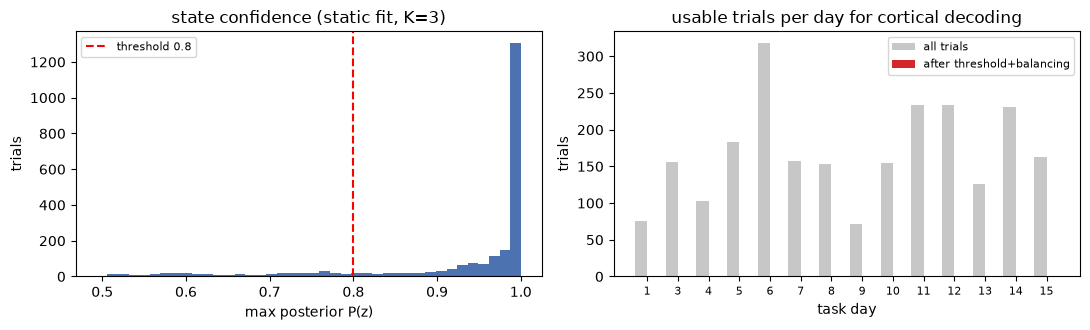

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(trA['p_max'], bins=40, color='#4c72b0')
axes[0].axvline(P_THRESHOLD, color='r', ls='--', label=f'threshold {P_THRESHOLD}')
axes[0].set_xlabel('max posterior P(z)'); axes[0].set_ylabel('trials'); axes[0].legend(fontsize=8)
axes[0].set_title('state confidence (static fit, K=%d)' % NUM_STATES)

xi = np.arange(len(bal))
axes[1].bar(xi - .2, bal['n_all'], width=.4, label='all trials', color='#c7c7c7')
axes[1].bar(xi + .2, bal['usable_balanced'], width=.4, label='after threshold+balancing', color='#d62728')
axes[1].set_xticks(xi); axes[1].set_xticklabels(day_stats['day_num'].astype(str), fontsize=8)
axes[1].set_xlabel('task day'); axes[1].set_ylabel('trials'); axes[1].legend(fontsize=8)
axes[1].set_title('usable trials per day for cortical decoding')
plt.tight_layout(); plt.show()

## 5. チェック4: `ssm` の `InputDrivenObservations(C=3)` で系統Bの静的フィットが回るか

要件5.4節の Step (1)（全day連結の静的GLM-HMM）を、系統B（3値）についても `ssm` の標準機能だけで学習できるかを確かめる。`ssm` の `InputDrivenObservations` は重み配列 `Wk` の形が `(K, C-1, M)` で、`calculate_logits()` が末尾にゼロ行を積む——つまり**最後のクラスが参照カテゴリ**。要件4.1節が参照カテゴリを No Reaction と定めているので、`yB` は Success=0 / Short Pull=1 / **No Reaction=2** と符号化する。

In [17]:
import ssm
import inspect
from ssm.observations import InputDrivenObservations
print('ssm:', ssm.__file__)
print('InputDrivenObservations signature:', inspect.signature(InputDrivenObservations.__init__))

def fit_categorical_glmhmm(ys_cat, xs_in, K, C, prior_sigma=PRIOR_SIGMA, seeds=SEEDS, num_iters=NUM_ITERS):
    best_model, best_score, best_lls = None, -np.inf, None
    M = int(xs_in[0].shape[1])
    for seed in seeds:
        np.random.seed(seed)
        m = ssm.HMM(K=K, D=1, M=M, observations='input_driven_obs',
                    observation_kwargs=dict(C=C, prior_mean=0, prior_sigma=prior_sigma),
                    transitions='standard')
        lls = m.fit(ys_cat, inputs=xs_in, method='em', num_iters=num_iters, tolerance=1e-4)
        score = float(lls[-1])
        print(f'  seed {seed}: log_prob={score:.2f}')
        if score > best_score:
            best_model, best_score, best_lls = m, score, lls
    return best_model, best_score, best_lls

ysB = [tr.loc[tr['task_day'] == d, ['yB']].to_numpy(dtype=int) for d in DAYS]
print('yB のカテゴリ内訳 (0=Success, 1=Short Pull, 2=No Reaction):', np.bincount(tr['yB']))
print()
print(f'系統B: Categorical GLM-HMM K={NUM_STATES}, C=3')
modelB, bestB, llsB = fit_categorical_glmhmm(ysB, xs, K=NUM_STATES, C=3)
print(f'best log_prob = {bestB:.2f}')
print('Wk shape (K, C-1, M):', modelB.observations.Wk.shape)

ssm: /mnt/c/Users/dmasu/braidyn-bc/.venv-wsl/lib/python3.12/site-packages/ssm/__init__.py
InputDrivenObservations signature: (self, K, D, M=0, C=2, prior_mean=0, prior_sigma=1000)
yB のカテゴリ内訳 (0=Success, 1=Short Pull, 2=No Reaction): [1293  511  555]

系統B: Categorical GLM-HMM K=3, C=3


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-2060.29


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-2059.76


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-2059.74
best log_prob = -2059.74
Wk shape (K, C-1, M): (3, 2, 3)


In [18]:
# 符号化の健全性確認: yB を2値へ潰して C=2 で学習すると、系統A（v4のBernoulli実装）と一致するはず
ys_collapsed = [(y == 2).astype(int) for y in ysB]   # No Reaction=1（最後=参照）, pulled=0
print('C=2（No Reactionを最後のクラスに置いた潰し版）')
_, best_collapsed, _ = fit_categorical_glmhmm(ys_collapsed, xs, K=NUM_STATES, C=2)
print()
print(f'系統A (v4.train_glmhmm_map, C=2)   log_prob = {bestA:.2f}')
print(f'C=2 潰し版                        log_prob = {best_collapsed:.2f}')
print(f'差 = {abs(bestA - best_collapsed):.4f}  （ラベルの入れ替えは尤度を変えないので、'
      f'一致すれば符号化とパラメータ化の対応が取れている）')

C=2（No Reactionを最後のクラスに置いた潰し版）


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-1006.11


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-1004.26


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-1005.86

系統A (v4.train_glmhmm_map, C=2)   log_prob = -1004.26
C=2 潰し版                        log_prob = -1004.26
差 = 0.0009  （ラベルの入れ替えは尤度を変えないので、一致すれば符号化とパラメータ化の対応が取れている）


In [19]:
# 状態ごとのカテゴリ確率（入力を平均値に固定したときの予測分布）と、系統Bの残存率
x_mean = np.array([1.0, 0.0, 0.0])   # bias=1, z化した2列の平均=0
W = modelB.observations.Wk           # (K, C-1, M)
logits = np.concatenate([W @ x_mean, np.zeros((W.shape[0], 1))], axis=1)   # 末尾に参照カテゴリの0
probs = np.exp(logits - logits.max(axis=1, keepdims=True))
probs /= probs.sum(axis=1, keepdims=True)
print('平均入力での 状態別カテゴリ確率:')
print(pd.DataFrame(probs, columns=['Success', 'Short Pull', 'No Reaction'],
                   index=[f'state {k}' for k in range(NUM_STATES)]).round(3).to_string())

zB, pB = v4.decode_states(modelB, ysB, xs)
trB = v4.attach_decoded_states(tr, zB, pB)
pcolsB = [c for c in trB.columns if c.startswith('p_state_')]
trB['p_max'] = trB[pcolsB].max(axis=1)
print()
print(f'系統B の P(z)>={P_THRESHOLD} 残存率: {(trB["p_max"] >= P_THRESHOLD).mean():.3f} '
      f'(系統A: {(trA["p_max"] >= P_THRESHOLD).mean():.3f})')
print()
print('系統B の 状態×試行タイプ（閾値適用後、全day合計）:')
keptB = trB[trB['p_max'] >= P_THRESHOLD]
print(pd.crosstab(keptB['state'], keptB['trial_type']).to_string())

平均入力での 状態別カテゴリ確率:
         Success  Short Pull  No Reaction
state 0    0.534       0.299        0.167
state 1    0.454       0.313        0.234
state 2    0.731       0.091        0.177

系統B の P(z)>=0.8 残存率: 0.852 (系統A: 0.844)

系統B の 状態×試行タイプ（閾値適用後、全day合計）:
trial_type  No Reaction  Short Pull  Success
state                                       
0                   302         284      492
1                    88         128      175
2                   116          35      389


## 6. まとめ

In [20]:
print('=' * 74)
print('Ver.5 実装前チェック まとめ  mouse=%s  days=%d  音提示試行=%d' % (MOUSE_ID, len(DAYS), len(tr)))
print('=' * 74)

rho_nr, p_nr, _, _ = trend(day_stats['p_no_reaction'], day_stats['day_idx'])
rho_sc, p_sc, _, _ = trend(day_stats['p_success_all'], day_stats['day_idx'])
rho_sg, p_sg, _, _ = trend(day_stats['p_success_given_pull'], day_stats['day_idx'])
rho_th, p_th, _, _ = trend(day_stats['thr_median'], day_stats['day_idx'])
print('[1] 学習曲線 (day index に対する Spearman rho, p)')
print(f'    No Reaction率           {rho_nr:+.3f} (p={p_nr:.3f})')
print(f'    Success率(全試行)        {rho_sc:+.3f} (p={p_sc:.3f})')
print(f'    Success率(押下試行内)     {rho_sg:+.3f} (p={p_sg:.3f})')
print(f'    報酬閾値(中央値)          {rho_th:+.3f} (p={p_th:.3f})')
print(f'    隣接day間のNo Reaction率変化: 平均 {np.abs(np.diff(dnr)).mean():.3f} / 最大 {np.abs(np.diff(dnr)).max():.3f}')

print()
print('[2] Short Pull の内訳と時間的まとまり')
for k, v in cnt.items():
    print(f'    {k:12s} {v:5d} ({v / len(sp) * 100:5.1f}%)')
for key, label in [('yA', 'yA'), ('short', 'ShortPull|pulled'), ('short_nodrop', 'ShortPull|pulled,途切れ除外')]:
    st, ac = res[key]
    print(f'    {label:30s} Stouffer z={st:+7.2f}  lag-1 ac={ac:+.3f}')
print(f'    3次元入力からのCV改善 (nats/試行): yA {gA:+.4f} / ShortPull {gB:+.4f} / 途切れ除外 {gC:+.4f}')

print()
print('[3] 皮質デコードの試行数')
print(f'    P(z)>={P_THRESHOLD} 残存率: 系統A {(trA["p_max"] >= P_THRESHOLD).mean():.3f} / '
      f'系統B {(trB["p_max"] >= P_THRESHOLD).mean():.3f}')
print(f'    day内バランシング後の使用可能試行: 中央値 {bal["usable_balanced"].median():.0f} '
      f'(最小 {bal["usable_balanced"].min()} / 最大 {bal["usable_balanced"].max()}), 全day計 {bal["usable_balanced"].sum()}')
print(f'    min_cell=0 のday: {(bal["min_cell"] == 0).sum()} / {len(bal)}')
print(f'    閾値なしでも 1状態が90%以上を占めるday: {int((dom >= 0.9).sum())} / {len(dom)} '
      f'(最頻状態占有率の中央値 {dom.median():.3f})')
print(f'    day内の状態切り替え: 合計 {len(rdf) - len(DAYS)} 回 / run長 中央値 {int(rdf["run_len"].median())} 試行')

print()
print('[4] ssm の多値対応')
print(f'    InputDrivenObservations(C=3) の学習: 成功 (log_prob={bestB:.2f}, Wk shape={modelB.observations.Wk.shape})')
print(f'    C=2 潰し版と系統Aの log_prob 差: {abs(bestA - best_collapsed):.4f}')
print('=' * 74)

Ver.5 実装前チェック まとめ  mouse=VG1GC-66  days=14  音提示試行=2359
[1] 学習曲線 (day index に対する Spearman rho, p)
    No Reaction率           -0.086 (p=0.771)
    Success率(全試行)        -0.354 (p=0.215)
    Success率(押下試行内)     -0.670 (p=0.009)
    報酬閾値(中央値)          +0.069 (p=0.815)
    隣接day間のNo Reaction率変化: 平均 0.175 / 最大 0.540

[2] Short Pull の内訳と時間的まとまり
    dropout        317 ( 62.0%)
    too_short      184 ( 36.0%)
    deadline         9 (  1.8%)
    unmeasured       1 (  0.2%)
    yA                             Stouffer z= -12.83  lag-1 ac=+0.249
    ShortPull|pulled               Stouffer z=  -2.34  lag-1 ac=+0.047
    ShortPull|pulled,途切れ除外         Stouffer z=  -2.88  lag-1 ac=+0.079
    3次元入力からのCV改善 (nats/試行): yA +0.1058 / ShortPull +0.0114 / 途切れ除外 +0.0074

[3] 皮質デコードの試行数
    P(z)>=0.8 残存率: 系統A 0.844 / 系統B 0.852
    day内バランシング後の使用可能試行: 中央値 0 (最小 0 / 最大 0), 全day計 0
    min_cell=0 のday: 14 / 14
    閾値なしでも 1状態が90%以上を占めるday: 11 / 14 (最頻状態占有率の中央値 1.000)
    day内の状態切り替え: 合計 3 回 / run長 中央値 153 試行

[4] ss